In [1]:
!pip install tensorflow matplotlib opencv-python

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import imghdr
import os
import numpy as np

In [3]:
#to avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
data_dir="drive/MyDrive/datahs"

In [5]:
for image_class in os.listdir(data_dir):
  print(image_class)

happy
sad


In [6]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
      image_path=os.path.join(data_dir, image_class, image)
      try:
        img=cv2.imread(image_path)
        tip=imghdr.what(image_path)
        if tip not in ['jpeg','jpg','png','bmp']:
          print('Image not in the correct format')
          os.remove(image_path)
      except Exception as e:
        print('Issue with image{}'.format(image_path))
        # os.remove(image_path)

In [7]:
data=tf.keras.utils.image_dataset_from_directory("drive/MyDrive/datahs")

Found 139 files belonging to 2 classes.


In [8]:
data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
data_iterator=data.as_numpy_iterator()

In [10]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x7838002b9240>)

In [11]:
# Get another batch from the iterator
batch=data_iterator.next()

In [12]:
# Images represented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [13]:
# Class 1=Sad people, 0=Happy people
batch[1]

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1], dtype=int32)

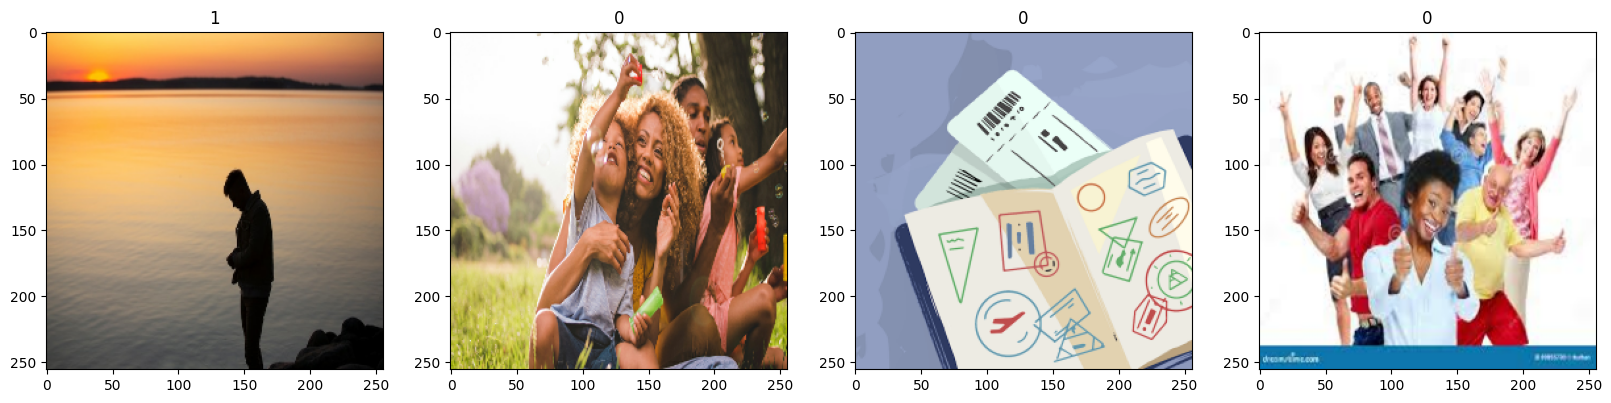

In [14]:
fig, ax=plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
  ax[idx].imshow(img.astype(int))
  ax[idx].title.set_text(batch[1][idx])

In [15]:
scaled=batch[0]/255

In [16]:
scaled.max()

1.0

## Preprocess the data

In [17]:
data= data.map(lambda x,y: (x/255, y))

In [18]:
scaled_iterator=data.as_numpy_iterator()

In [19]:
batch1=scaled_iterator.next()

In [20]:
batch1[0].max()

1.0

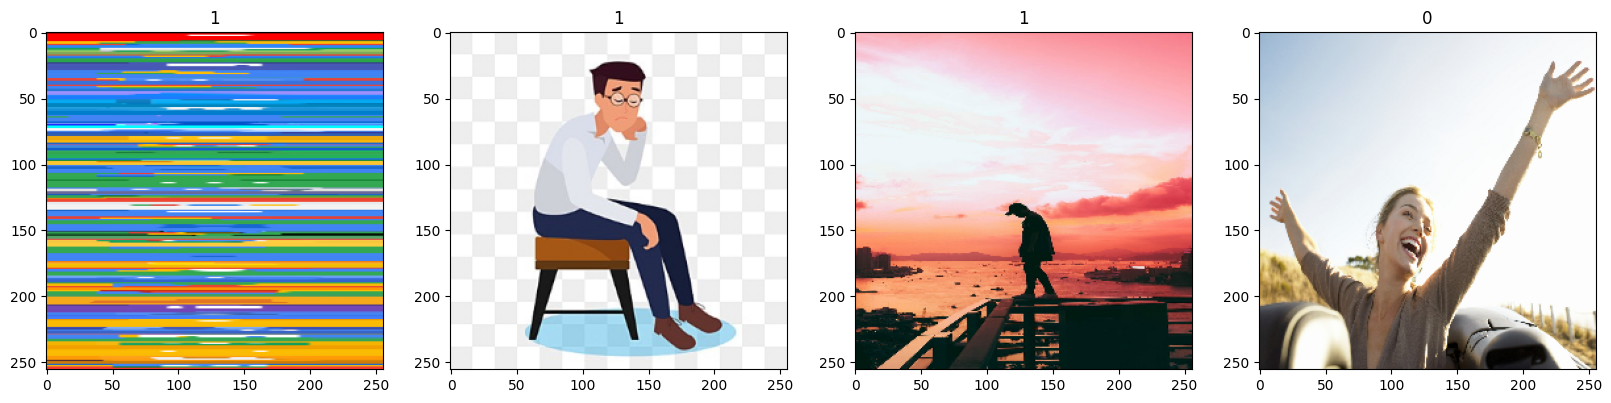

In [21]:
fig, ax=plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch1[0][:4]):
  ax[idx].imshow(img)
  ax[idx].title.set_text(batch1[1][idx])

In [22]:
len(data)

5

In [23]:
train_size=int(len(data)*.7)
val_size=int(len(data)*.2)
test_size=int(len(data)*.1)+1

In [24]:
test_size

1

In [25]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)


In [26]:
len(test)

1

In [27]:
!pip install --upgrade tensorflow


In [28]:
import tensorflow as tf
print(tf.__version__)



2.17.0


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [30]:
model= Sequential()

In [31]:
#
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
logdir="drive/MyDrive/logs"

In [35]:
tensorboard_callback= tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [36]:
hist=model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4727 - loss: 1.5611 - val_accuracy: 0.4688 - val_loss: 1.6242
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 892ms/step - accuracy: 0.4622 - loss: 1.3385 - val_accuracy: 0.5938 - val_loss: 0.6417
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 780ms/step - accuracy: 0.5599 - loss: 0.6269 - val_accuracy: 0.7188 - val_loss: 0.6146
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 952ms/step - accuracy: 0.6901 - loss: 0.6229 - val_accuracy: 0.7812 - val_loss: 0.5839
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8203 - loss: 0.5739 - val_accuracy: 0.8125 - val_loss: 0.4758
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 936ms/step - accuracy: 0.6719 - loss: 0.5417 - val_accuracy: 0.8750 - val_loss: 0.4411
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 849ms/step - accuracy: 0.7695 - loss: 0.4824 - val_accuracy: 0.6875 - val_loss: 0.4963
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 832ms/step - accuracy: 0.7747 - loss: 0.4596 - val_accuracy: 0.7812 - val_loss: 0.47

In [37]:
hist

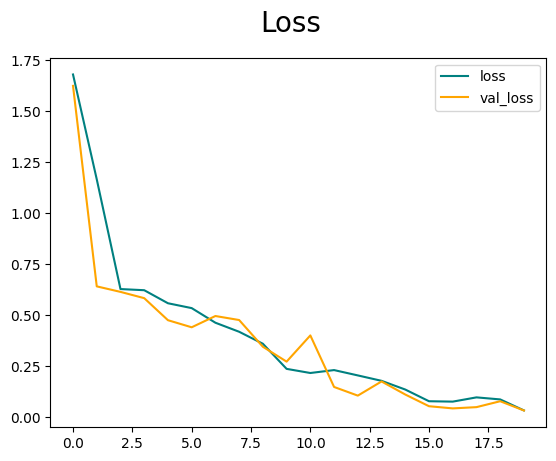

In [38]:
fig=plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper right")
plt.show()

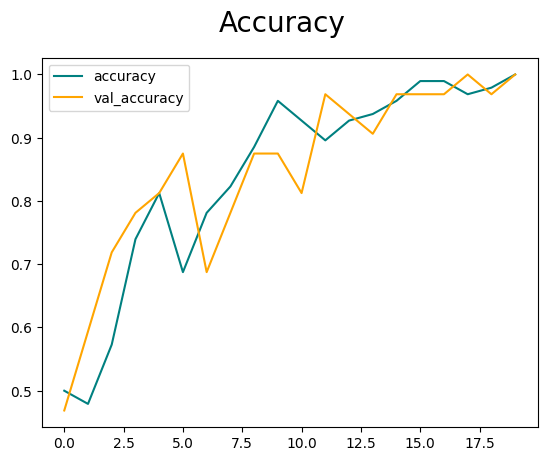

In [39]:
fig=plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [40]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [41]:
pre=Precision()
re= Recall()
acc=BinaryAccuracy()

In [42]:
for batch in test.as_numpy_iterator():
  x, y=batch
  yhat=model.predict(x)
  pre.update_state(y, yhat)
  re.update_state(y, yhat)
  acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step


In [43]:
print(f'Precision:{pre.result().numpy()}, Reacll:{re.result().numpy()}, Accuracy:{acc.result().numpy()}')

Precision:1.0, Reacll:1.0, Accuracy:1.0


In [44]:
import cv2

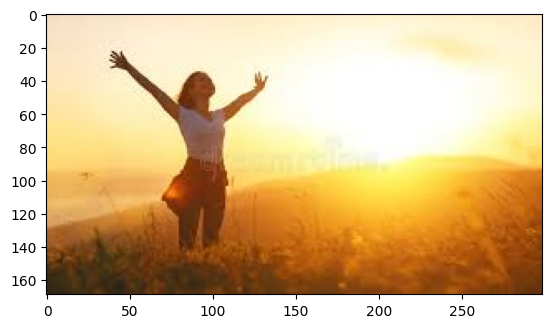

In [45]:
img=cv2.imread("drive/MyDrive/happytest.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGBA))
plt.show()

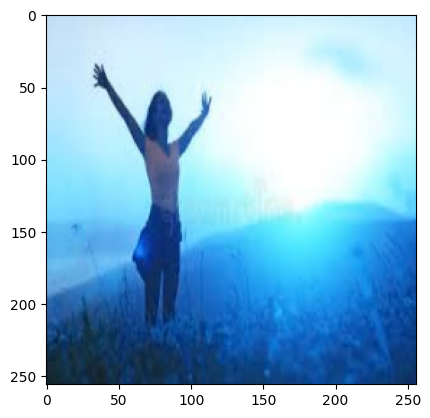

In [46]:
resize=tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [47]:
yhat=model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [48]:
yhat

array([[0.03414876]], dtype=float32)

In [49]:
if yhat > 0.5:
  print(f'Predicted class is Sad')
else:
  print(f'Predicted class is Happy')



Predicted class is Happy


In [50]:
from tensorflow.keras.models import load_model

In [51]:
model.save(os.path.join('drive/MyDrive/models', 'happy-sad-model.h5'))

In [52]:
os.path.join('drive/MyDrive/models', 'happy-sad-model.h5')

'drive/MyDrive/models/happy-sad-model.h5'

In [53]:
new_model=load_model(os.path.join('drive/MyDrive/models','happy-sad-model.h5'))

In [54]:
new_model

<Sequential name=sequential, built=True>

In [55]:
newyhat=new_model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step


In [56]:
if newyhat > 0.5:
  print(f'Predicted class is Sad')
else:
  print(f'Predicted class is Happy')

Predicted class is Happy
